In [ ]:
%matplotlib widget
import inspect
import math
import re

import matplotlib.pyplot as plt
import numpy as np
import torch
import warp as wp

from warpSPHCore import *
from warpSPHCore.util import generateNeighborTestData

# Initialize Warp
wp.config.verify_autograd_array_access = False
wp.config.verbose = False
wp.init()

def debugPrint(x):
    frame = inspect.currentframe().f_back
    s = inspect.getframeinfo(frame).code_context[0]
    r = re.search(r"\((.*)\)", s).group(1)
    print("{} [{}] = {}".format(r, type(x).__name__, x))

def plot_scalar_field(ax, positions, values, title, *, cmap="viridis", marker_size=2, domain=None):
    sc = ax.scatter(positions[:, 0].cpu(), positions[:, 1].cpu(), c=values.cpu(), cmap=cmap, s=marker_size)
    ax.figure.colorbar(sc, ax=ax, shrink=0.95)
    ax.set_title(title)
    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.set_aspect("equal")
    if domain is not None:
        ax.set_xlim(domain.min[0].item(), domain.max[0].item())
        ax.set_ylim(domain.min[1].item(), domain.max[1].item())
    return sc

def plot_vector_components(fig, axes, positions, tensor_field, title_prefix, *, marker_size=2, domain=None, cmap="RdBu_r"):
    component_titles = [(0, 0), (0, 1), (1, 0), (1, 1)]
    for ax, (row, col) in zip(axes.flat, component_titles):
        component = tensor_field[:, row, col]
        sc = ax.scatter(positions[:, 0].cpu(), positions[:, 1].cpu(), c=component.cpu(), cmap=cmap, s=marker_size)
        ax.figure.colorbar(sc, ax=ax, shrink=0.95)
        ax.set_title(f"{title_prefix} [{row},{col}]")
        ax.set_xlabel("X")
        ax.set_ylabel("Y")
        ax.set_aspect("equal")
        if domain is not None:
            ax.set_xlim(domain.min[0].item(), domain.max[0].item())
            ax.set_ylim(domain.min[1].item(), domain.max[1].item())
        fig.colorbar(sc, ax=ax, shrink=0.95)

def make_jittered_particles(base_positions, base_supports, base_masses, base_kinds, jitter_scale, dx, device):
    jitter = jitter_scale * dx * torch.randn_like(base_positions)
    jittered_positions = (base_positions + jitter).contiguous()
    return ParticleState(
        positions=jittered_positions,
        supports=base_supports.contiguous(),
        masses=base_masses.contiguous(),
        densities=None,
        kinds=base_kinds,
    )


Warp DeprecationWarning: warp.config.verbose is deprecated; use warp.config.log_level = warp.LOG_DEBUG instead.


Warp 1.15.0 initialized:
   CUDA Toolkit 12.9, Driver 13.3
   Devices:
     "cpu"      : "CPU"
     "cuda:0"   : "NVIDIA GeForce RTX 3090" (24 GiB, sm_86, mempool enabled)
   Kernel cache:
     /home/veldora/.cache/warp/1.15.0


In [2]:
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
targetNumNeighbors = 50
nx = 128
dim = 2
numParticles = nx ** dim

warpOnly = False
periodic = True
field_mode = "periodic_sinusoidal"  # "linear" or "periodic_sinusoidal"
mask_edge_particles = True  # used for linear fields to hide the periodic jump at the boundaries
jitter = 0.05
linear_slope_x = 5.0
linear_slope_y = 0.0

kernel = KernelFunctions.Wendland2
supportMode = SupportScheme.Gather

markerSize = 8 if warpOnly else 2
gridVisualization = False
gridResolution = 128
dx = 2.0 / nx


In [3]:
positions, supports, _, domain, dx = generateNeighborTestData(
    nx, targetNumNeighbors, dim, periodic, device
)

masses = torch.full((positions.shape[0],), dx ** dim, device=device, dtype=positions.dtype)
kinds = torch.zeros(positions.shape[0], device=device, dtype=torch.int32)

particles = ParticleState(
    positions=positions.contiguous(),
    supports=supports.contiguous(),
    masses=masses.contiguous(),
    densities=None,
    kinds=kinds,
)

adjacency = radiusSearchCompactHashMap(
    particles,
    domain,
    mode=SupportScheme.SuperSymmetric,
)

densities = warpOperation(
    particles,
    OperationProperties(
        kernel=kernel,
        operation=WarpOperation.Density,
        supportMode=supportMode,
        operationMode=OperationDirection.AllToAll,
    ),
    domain,
    adjacency=adjacency,
)
particles.densities = densities

def make_scalar_field(x, y):
    if field_mode == "periodic_sinusoidal":
        return torch.sin(math.pi * x) * torch.cos(math.pi * y)
    return linear_slope_x * x + linear_slope_y * y + 10.0

def make_vector_field(x, y):
    if field_mode == "periodic_sinusoidal":
        return torch.stack((torch.sin(math.pi * x), torch.cos(math.pi * y)), dim=1)
    return torch.stack((2.0 * x + y, -x + 0.5 * y), dim=1)

scalar_field = make_scalar_field(positions[:, 0], positions[:, 1])
vector_field = make_vector_field(positions[:, 0], positions[:, 1])

jittered_particles = make_jittered_particles(
    positions,
    supports,
    masses,
    kinds,
    jitter,
    dx,
    device,
)

jittered_adjacency = radiusSearchCompactHashMap(
    jittered_particles,
    domain,
    mode=SupportScheme.SuperSymmetric,
)

jittered_densities = warpOperation(
    jittered_particles,
    OperationProperties(
        kernel=kernel,
        operation=WarpOperation.Density,
        supportMode=supportMode,
        operationMode=OperationDirection.AllToAll,
    ),
    domain,
    adjacency=jittered_adjacency,
)
jittered_particles.densities = jittered_densities

apparent_area, crk_density, crk_state = computeCRKFactors(
    jittered_particles,
    domain,
    kernel,
    operationMode=OperationDirection.AllToAll,
    adjacency=jittered_adjacency,
)

if field_mode == "periodic_sinusoidal":
    plot_mask = torch.ones(positions.shape[0], dtype=torch.bool, device=positions.device)
else:
    plot_mask = torch.ones(positions.shape[0], dtype=torch.bool, device=positions.device)
    if mask_edge_particles:
        band = 4.0 * dx
        for axis_idx in range(dim):
            plot_mask = plot_mask & (positions[:, axis_idx] > domain.min[axis_idx] + band)
            plot_mask = plot_mask & (positions[:, axis_idx] < domain.max[axis_idx] - band)


Module sphWarpCore.radiusSearch.compactHash.wp_index cb8e58c load on device 'cuda:0' took 1.28 ms  (cached)
Module sphWarpCore.radiusSearch.compactHash.wp_hashCells 69952ab load on device 'cuda:0' took 1.01 ms  (cached)
Module sphWarpCore.radiusSearch.compactHash.wp_countNeighbors b9d3a6a load on device 'cuda:0' took 1.78 ms  (cached)
Module sphWarpCore.radiusSearch.compactHash.wp_collectNeighbors ed2da4a load on device 'cuda:0' took 1.36 ms  (cached)
Module sphWarpCore.coreOperations.wp_density 104e205 load on device 'cuda:0' took 5.92 ms  (cached)
Module sphWarpCore.crk.crk_volume 1e3d4cf load on device 'cuda:0' took 4.56 ms  (cached)
Module sphWarpCore.crk.crk_moments 99937f4 load on device 'cuda:0' took 14116.48 ms  (compiled)
Module sphWarpCore.crk.crk_density e75606e load on device 'cuda:0' took 3.03 ms  (cached)


Module sphWarpCore.coreOperations.wp_gradient 227535d load on device 'cuda:0' took 6.32 ms  (cached)
Linear scalar gradient MAE X: 0.006049483548849821
Linear scalar gradient MAE Y: 0.00604944908991456


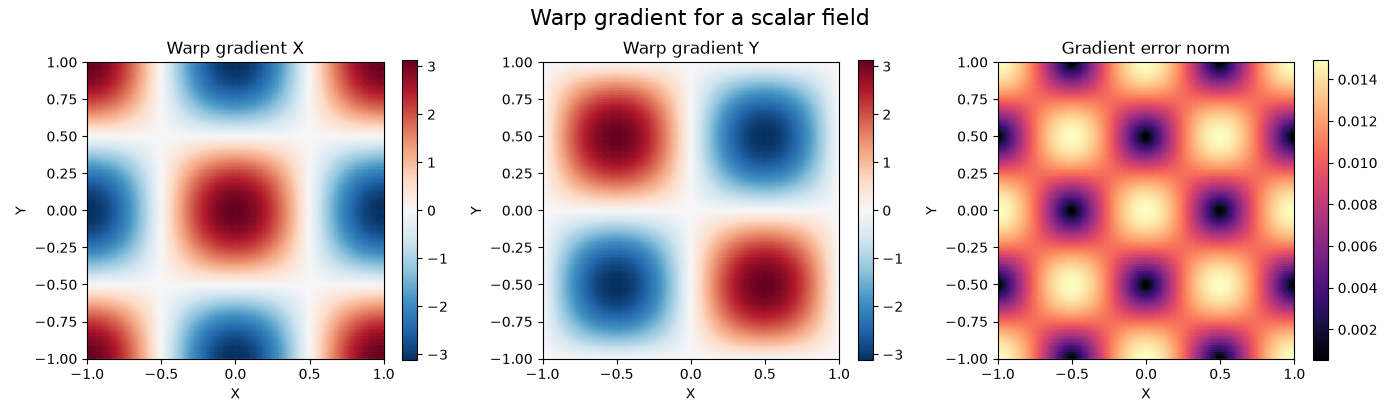

In [4]:
linear_gradient_warp = warpOperation(
    particles,
    queryValues=scalar_field,
    referenceValues=scalar_field,
    operationProperties=OperationProperties(
        kernel=kernel,
        supportMode=supportMode,
        operation=WarpOperation.Gradient,
        gradientMode=GradientScheme.Difference,
        operationMode=OperationDirection.AllToAll,
    ),
    adjacency=adjacency,
    domain=domain,
)

analytic_scalar_gradient = torch.zeros((scalar_field.shape[0], 2), device=device, dtype=scalar_field.dtype)
if field_mode == "periodic_sinusoidal":
    analytic_scalar_gradient[:, 0] = math.pi * torch.cos(math.pi * positions[:, 0]) * torch.cos(math.pi * positions[:, 1])
    analytic_scalar_gradient[:, 1] = -math.pi * torch.sin(math.pi * positions[:, 0]) * torch.sin(math.pi * positions[:, 1])
else:
    analytic_scalar_gradient[:, 0] = linear_slope_x
    analytic_scalar_gradient[:, 1] = linear_slope_y
scalar_gradient_error = torch.abs(linear_gradient_warp - analytic_scalar_gradient)

fig, axis = plt.subplots(1, 3, figsize=(14, 4), squeeze=False)
plot_scalar_field(axis[0, 0], positions[plot_mask], linear_gradient_warp[:, 0][plot_mask], "Warp gradient X", cmap="RdBu_r", marker_size=markerSize, domain=domain)
plot_scalar_field(axis[0, 1], positions[plot_mask], linear_gradient_warp[:, 1][plot_mask], "Warp gradient Y", cmap="RdBu_r", marker_size=markerSize, domain=domain)
plot_scalar_field(axis[0, 2], positions[plot_mask], scalar_gradient_error.norm(dim=1)[plot_mask], "Gradient error norm", cmap="magma", marker_size=markerSize, domain=domain)
fig.suptitle("Warp gradient for a scalar field", fontsize=16)
fig.tight_layout()
print("Linear scalar gradient MAE X:", torch.mean(scalar_gradient_error[:, 0]).item())
print("Linear scalar gradient MAE Y:", torch.mean(scalar_gradient_error[:, 1]).item())


Module sphWarpCore.coreOperations.wp_gradient 5e3edff load on device 'cuda:0' took 9.91 ms  (cached)
Vector gradient shape: (16384, 2, 2)
Vector gradient mean abs error: 0.0034260922111570835


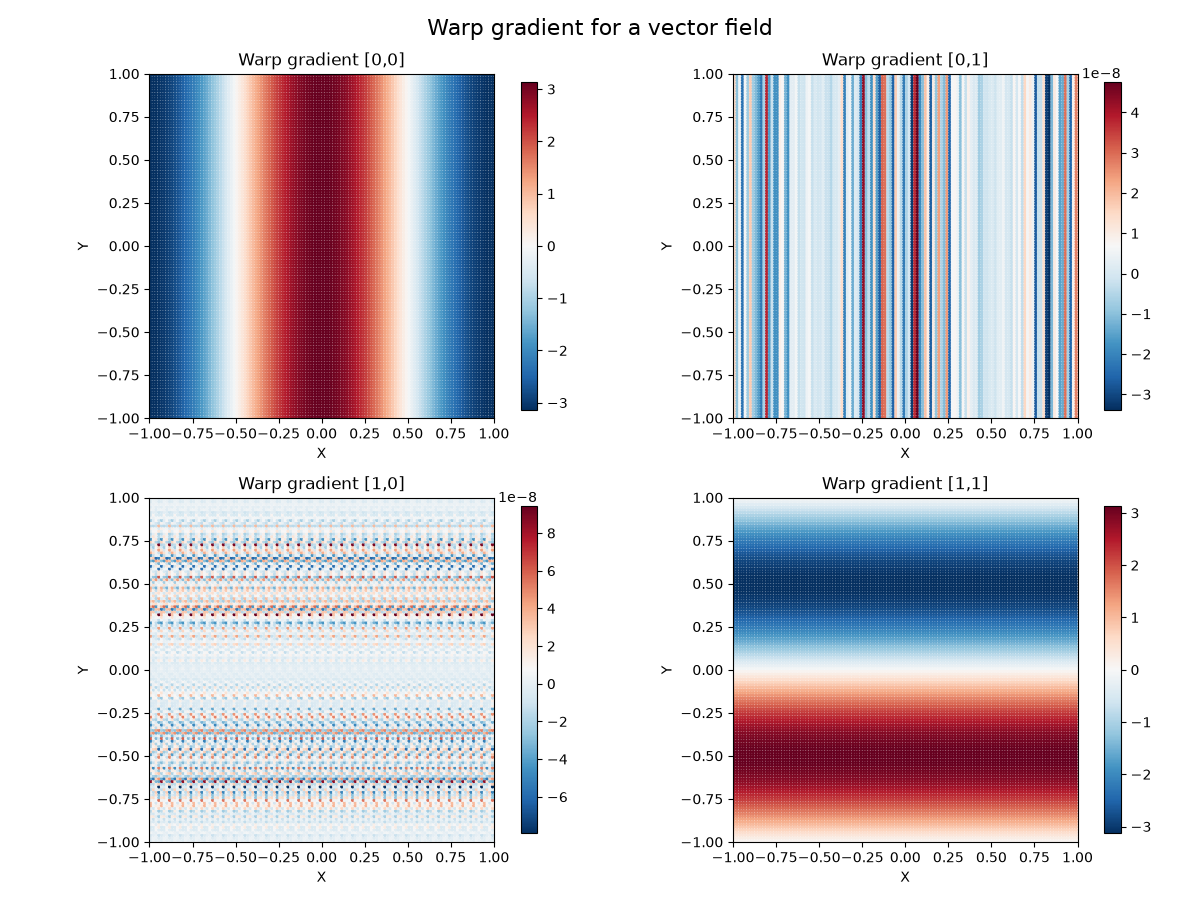

In [5]:
vector_gradient_warp = warpOperation(
    particles,
    queryValues=vector_field,
    referenceValues=vector_field,
    operationProperties=OperationProperties(
        kernel=kernel,
        supportMode=supportMode,
        operation=WarpOperation.Gradient,
        gradientMode=GradientScheme.Difference,
        operationMode=OperationDirection.AllToAll,
    ),
    adjacency=adjacency,
    domain=domain,
)

analytic_vector_gradient = torch.zeros_like(vector_gradient_warp)
if field_mode == "periodic_sinusoidal":
    analytic_vector_gradient[:, 0, 0] = math.pi * torch.cos(math.pi * positions[:, 0])
    analytic_vector_gradient[:, 0, 1] = 0.0
    analytic_vector_gradient[:, 1, 0] = 0.0
    analytic_vector_gradient[:, 1, 1] = -math.pi * torch.sin(math.pi * positions[:, 1])
else:
    analytic_vector_gradient[:, 0, 0] = 2.0
    analytic_vector_gradient[:, 0, 1] = 1.0
    analytic_vector_gradient[:, 1, 0] = -1.0
    analytic_vector_gradient[:, 1, 1] = 0.5
vector_gradient_error = torch.abs(vector_gradient_warp - analytic_vector_gradient)

fig, axis = plt.subplots(2, 2, figsize=(12, 9), squeeze=False)
for row, col in ((0, 0), (0, 1), (1, 0), (1, 1)):
    title = f"Warp gradient [{row},{col}]"
    plot_scalar_field(axis[row, col], positions[plot_mask], vector_gradient_warp[:, row, col][plot_mask], title, cmap="RdBu_r", marker_size=markerSize, domain=domain)
fig.suptitle("Warp gradient for a vector field", fontsize=16)
fig.tight_layout()
print("Vector gradient shape:", tuple(vector_gradient_warp.shape))
print("Vector gradient mean abs error:", vector_gradient_error.mean().item())


Plain jittered gradient MAE: 0.017218489199876785
CRK jittered gradient MAE: 0.003745106980204582


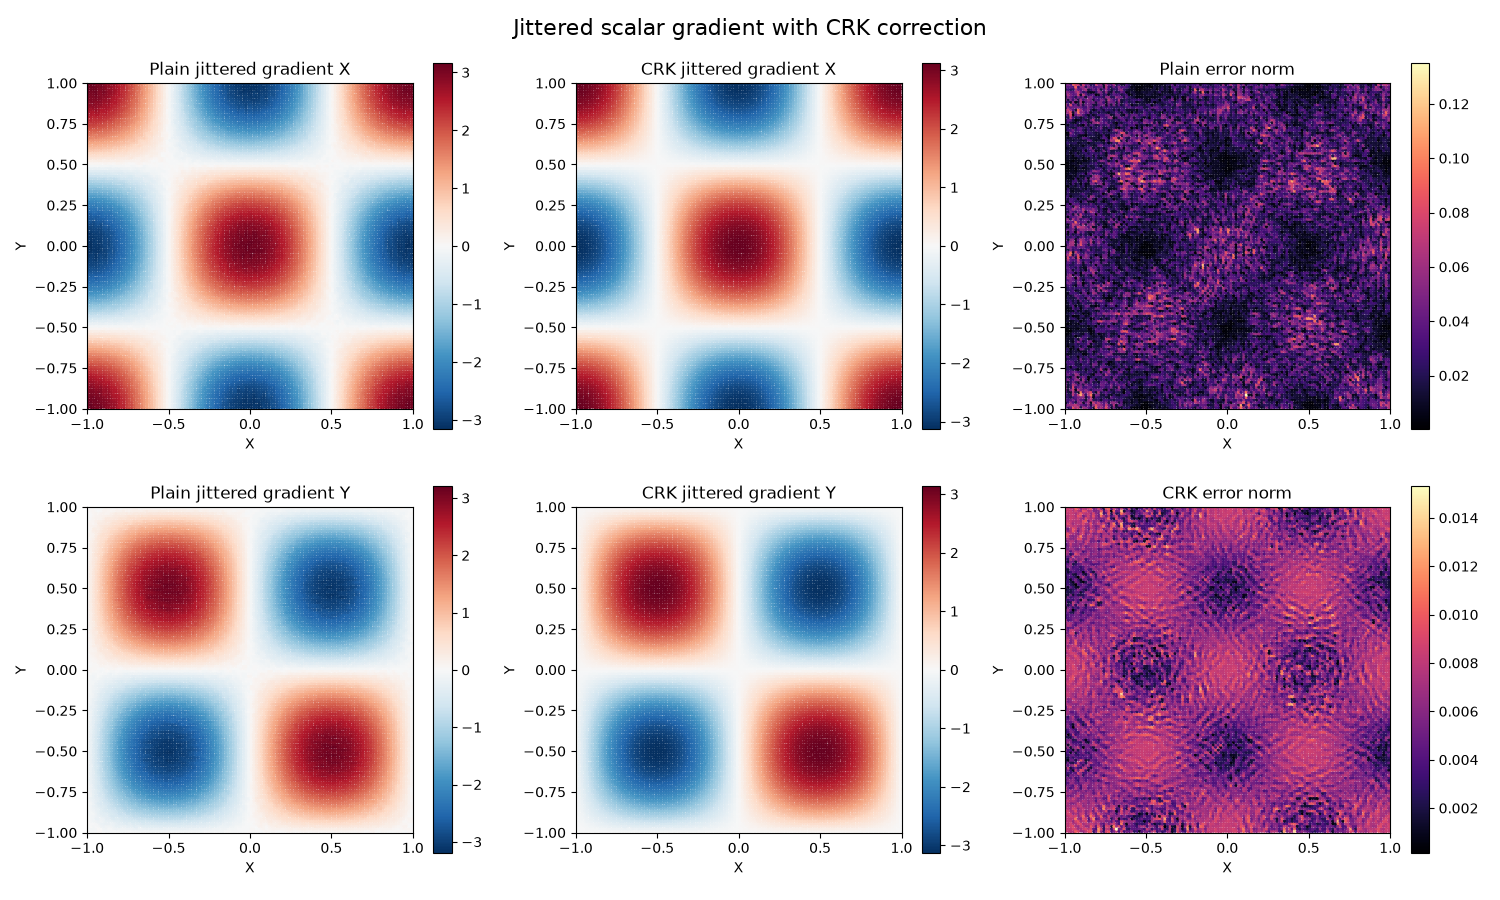

In [6]:
scalar_field_jittered = make_scalar_field(jittered_particles.positions[:, 0], jittered_particles.positions[:, 1])

plain_jittered_gradient = warpOperation(
    jittered_particles,
    queryValues=scalar_field_jittered,
    referenceValues=scalar_field_jittered,
    operationProperties=OperationProperties(
        kernel=kernel,
        supportMode=supportMode,
        operation=WarpOperation.Gradient,
        gradientMode=GradientScheme.Difference,
        operationMode=OperationDirection.AllToAll,
    ),
    adjacency=jittered_adjacency,
    domain=domain,
)

crk_jittered_gradient = warpOperation(
    jittered_particles,
    queryValues=scalar_field_jittered,
    referenceValues=scalar_field_jittered,
    operationProperties=OperationProperties(
        kernel=kernel,
        supportMode=SupportScheme.SuperSymmetric,
        operation=WarpOperation.Gradient,
        gradientMode=GradientScheme.Difference,
        operationMode=OperationDirection.AllToAll,
    ),
    adjacency=jittered_adjacency,
    domain=domain,
    crkState=crk_state,
    queryVolumes=apparent_area,
    referenceVolumes=apparent_area,
)

analytic_jittered_gradient = torch.zeros((scalar_field_jittered.shape[0], 2), device=device, dtype=scalar_field_jittered.dtype)
if field_mode == "periodic_sinusoidal":
    analytic_jittered_gradient[:, 0] = math.pi * torch.cos(math.pi * jittered_particles.positions[:, 0]) * torch.cos(math.pi * jittered_particles.positions[:, 1])
    analytic_jittered_gradient[:, 1] = -math.pi * torch.sin(math.pi * jittered_particles.positions[:, 0]) * torch.sin(math.pi * jittered_particles.positions[:, 1])
else:
    analytic_jittered_gradient[:, 0] = linear_slope_x
    analytic_jittered_gradient[:, 1] = linear_slope_y
crk_jittered_error = torch.abs(crk_jittered_gradient - analytic_jittered_gradient)
plain_jittered_error = torch.abs(plain_jittered_gradient - analytic_jittered_gradient)

fig, axis = plt.subplots(2, 3, figsize=(15, 9), squeeze=False)
plot_scalar_field(axis[0, 0], jittered_particles.positions[plot_mask], plain_jittered_gradient[:, 0][plot_mask], "Plain jittered gradient X", cmap="RdBu_r", marker_size=markerSize, domain=domain)
plot_scalar_field(axis[1, 0], jittered_particles.positions[plot_mask], plain_jittered_gradient[:, 1][plot_mask], "Plain jittered gradient Y", cmap="RdBu_r", marker_size=markerSize, domain=domain)
plot_scalar_field(axis[0, 1], jittered_particles.positions[plot_mask], crk_jittered_gradient[:, 0][plot_mask], "CRK jittered gradient X", cmap="RdBu_r", marker_size=markerSize, domain=domain)
plot_scalar_field(axis[1, 1], jittered_particles.positions[plot_mask], crk_jittered_gradient[:, 1][plot_mask], "CRK jittered gradient Y", cmap="RdBu_r", marker_size=markerSize, domain=domain)
plot_scalar_field(axis[0, 2], jittered_particles.positions[plot_mask], plain_jittered_error.norm(dim=1)[plot_mask], "Plain error norm", cmap="magma", marker_size=markerSize, domain=domain)
plot_scalar_field(axis[1, 2], jittered_particles.positions[plot_mask], crk_jittered_error.norm(dim=1)[plot_mask], "CRK error norm", cmap="magma", marker_size=markerSize, domain=domain)
fig.suptitle("Jittered scalar gradient with CRK correction", fontsize=16)
fig.tight_layout()
print("Plain jittered gradient MAE:", plain_jittered_error[plot_mask].mean().item())
print("CRK jittered gradient MAE:", crk_jittered_error[plot_mask].mean().item())
